In [1]:
import pandas as pd

X_train = pd.read_csv("X_train_scaled.csv")
X_test = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv").squeeze()  # squeeze() to turn into Series
y_test = pd.read_csv("y_test.csv").squeeze()



=== Euclidean Distance (p=2) ===
Accuracy: 0.7252
ROC-AUC:  0.7914

Classification Report:
              precision    recall  f1-score   support

           0      0.745     0.685     0.714      7070
           1      0.708     0.765     0.736      7069

    accuracy                          0.725     14139
   macro avg      0.727     0.725     0.725     14139
weighted avg      0.727     0.725     0.725     14139



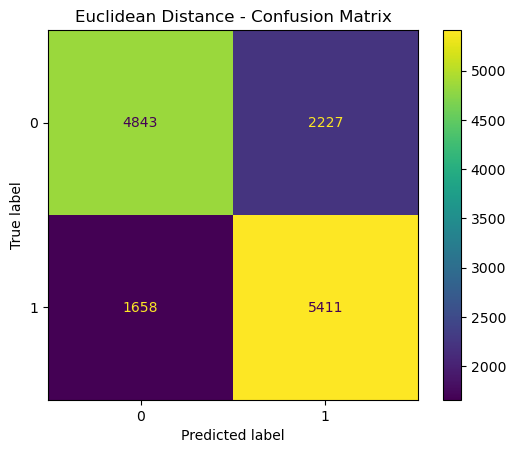


=== Manhattan Distance (p=1) ===
Accuracy: 0.7270
ROC-AUC:  0.7912

Classification Report:
              precision    recall  f1-score   support

           0      0.745     0.690     0.717      7070
           1      0.711     0.764     0.737      7069

    accuracy                          0.727     14139
   macro avg      0.728     0.727     0.727     14139
weighted avg      0.728     0.727     0.727     14139



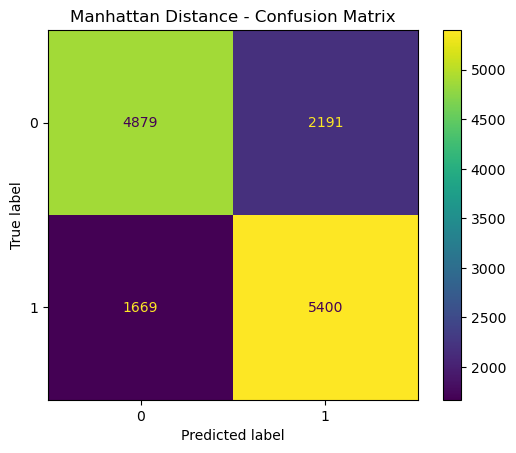



 COMPARISON TABLE 
     Metric  Euclidean  Manhattan
0  Accuracy   0.725228   0.726996
1   ROC-AUC   0.791403   0.791160


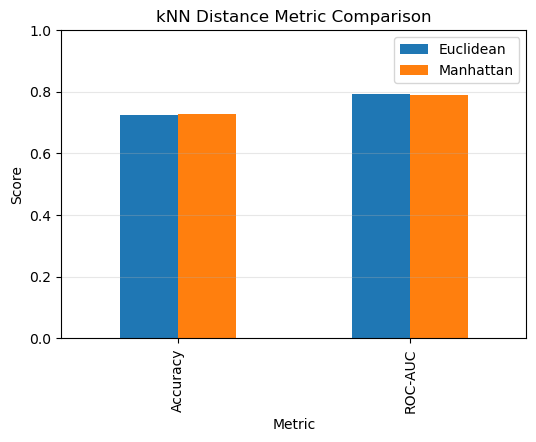

In [2]:
# Train kNN: Euclidean vs Manhattan

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

#  Helper function to train + evaluate 
def evaluate_knn(p_value, name):
    """
    p=1 -> Manhattan
    p=2 -> Euclidean
    """
    knn = KNeighborsClassifier(n_neighbors=9, p=p_value, weights="uniform")  # start with k=9
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, digits=3)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {name} Distance (p={p_value}) ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print("\nClassification Report:")
    print(report)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"{name} Distance - Confusion Matrix")
    plt.show()

    return acc, auc

# Train + compare
acc_euclid, auc_euclid = evaluate_knn(2, "Euclidean")
acc_manh, auc_manh = evaluate_knn(1, "Manhattan")

#Compare results
results = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Euclidean": [acc_euclid, auc_euclid],
    "Manhattan": [acc_manh, auc_manh]
})
print("\n\n COMPARISON TABLE ")
print(results)

results.plot(x="Metric", kind="bar", figsize=(6,4), title="kNN Distance Metric Comparison", legend=True)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.show()
